In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

%load_ext autoreload
%autoreload 2
%matplotlib inline

cwd = Path.cwd().resolve()

# Locate helper_function by searching upward first, then common workspace locations.
def find_helper_folder(start: Path) -> Path:
    # 1) Directly in current/parent tree
    for p in [start, *start.parents]:
        candidate = p / "helper_function"
        if candidate.is_dir():
            return candidate

    raise FileNotFoundError("Could not find helper_function folder")


helper_path = find_helper_folder(cwd)
project_root = helper_path.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(helper_path) not in sys.path:
    sys.path.insert(0, str(helper_path))

print("Project root:", project_root)
print("Current working directory:", cwd)
print("helper_function path:", helper_path)
print("helper_function exists:", helper_path.exists())

Project root: /Users/JackX/projects/trap_sim_nullspace
Current working directory: /Users/JackX/projects/trap_sim_nullspace/lionix_gate/output_file/dc
helper_function path: /Users/JackX/projects/trap_sim_nullspace/helper_function
helper_function exists: True


In [2]:
charge = 1.602176634e-19  # Coulombs
mass = 40 * 1.66053906660e-27  # kg (mass of Ca+ ion)
Omega = 2 * np.pi * 50e6  # rad/s (RF drive frequency)
pseudo_factor = charge / (4 * mass * Omega**2)

## Get grad and hessian of potential for each electrodes at x0, y0, z0

In [3]:
from post_process import read_post_processed
from field_analysis import analyze_dc_pot

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_sim_out.h5", electrode_list=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25}


In [ ]:
dc_fields = {}

x0 = 0
y0 = 0
z0 = 49.99e-6

dr = 2e-6

for i in excitation_electrodes:
    
    coeff, phi, grad, hessian = analyze_dc_pot(x, y, z, potentials[i], x0, y0, z0, dr)

    dc_fields[i] = (coeff, phi, grad, hessian)

NameError: name 'excitation_electrodes' is not defined

To achieve axial trapping of ion at x0, y0, and z0 with $\omega_0 = 2 \pi\times1$ MHz, we would have grad = [0, 0, 0], hessian = $\alpha$ [[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]], with $\alpha = \frac{m \omega_0^2}{q}$

In [33]:
from field_analysis import fit_prep, print_field, quadratic_sol

omega = 2 * np.pi * 1e6

A, b = fit_prep(dc_fields, excitation_electrodes, target_phi = np.array([0]), target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))

L, x = quadratic_sol(A, b)
print(x)
print_field(A@x, delta_pos=True)

[ 0.02427275  0.08069356  0.28237506  0.52870213 -2.16433457  0.52774995
  0.28926691  0.08511585  0.02720509 -0.26873243 -0.2691644   0.02368037
  0.08135771  0.28285288  0.52985218 -2.16533656  0.52741273  0.28921232
  0.08419908  0.02795913]
Phi: -0.18628353142607834
Grad: [ 0.02534928 -0.00011679  0.0217907 ]
Hessian: [[ 1.63665986e+07  2.33712854e-08 -1.87685430e-06]
 [ 2.33712854e-08 -8.18329931e+06  0.00000000e+00]
 [-1.87685430e-06  0.00000000e+00 -8.18329931e+06]]
Delta Pos (um): [-1.54884254e-03 -1.42715447e-05  2.66282625e-03]


In [34]:
A.T @ A

Array([[ 7.98313097e+10,  1.71170418e+11,  4.59353328e+11,
         1.36269788e+12,  1.32434113e+12,  1.86630773e+11,
        -3.65653833e+10, -3.26054369e+10, -2.09150149e+10,
        -1.52690068e+13,  5.02925429e+12,  2.92787350e+10,
         6.05821070e+10,  1.26941367e+11,  1.11601801e+11,
        -3.85179881e+11, -5.15053958e+11, -2.69312370e+11,
        -1.19534220e+11, -6.11700395e+10],
       [ 1.71170418e+11,  3.73209037e+11,  1.02901774e+12,
         3.25057527e+12,  3.57578281e+12,  6.58734288e+11,
        -8.69386666e+09, -4.59043919e+10, -3.48120318e+10,
        -3.88131582e+13,  4.69881267e+12,  5.97065308e+10,
         1.27694733e+11,  2.80978407e+11,  3.73796050e+11,
        -9.09627515e+10, -6.52807984e+11, -4.72880765e+11,
        -2.24113092e+11, -1.17738635e+11],
       [ 4.59353328e+11,  1.02901774e+12,  2.97222178e+12,
         1.04717170e+13,  1.38855422e+13,  2.98591996e+12,
         2.92672372e+11, -9.49543875e+09, -4.38417932e+10,
        -1.37193750e+14, -1.3

In [6]:
coeff, *_ = jnp.linalg.lstsq(A, b, rcond=None)

In [7]:
for i in range(len(coeff)):
    print(excitation_electrodes[i], coeff[i])
print_field(A@coeff, delta_pos=True)

3 -1.9575305364355098
4 -2.593056698488063
5 -2.37761121356436
6 3.4103716292495827
7 -1.7482602991293157
8 3.403766549712093
9 -2.3729186189659193
10 -2.567494202950015
11 -1.9266007077938543
12 -0.007007328560955989
15 -0.0068985385546497125
16 -1.9592019742595965
17 -2.591118106216529
18 -2.3807810625173067
19 3.408182371039308
21 -1.7446294540711953
22 3.3965365599665858
23 -2.3663896660652743
24 -2.5770935199564193
25 -1.9185808185714341
Phi: -4.773889871330069e-09
Grad: [8.36168246e-10 3.67508619e-08 2.87402990e-10]
Hessian: [[ 1.63665986e+07  4.19458956e-09  5.82076609e-10]
 [ 4.19458956e-09 -8.18329931e+06 -1.04308128e-07]
 [ 5.82076609e-10 -1.04308128e-07 -8.18329931e+06]]
Delta Pos (um): [-5.10899219e-11  4.49095903e-09  3.51206744e-11]


Now to compare with voltage sets from before, using 5 electrodes from each side : 5, 6, 7, 8, 9, 18, 19, 21, 22, 23 and 12, 15 at the center

In [27]:
selected_electrodes = [5, 6, 7, 8, 9, 12, 15, 18, 19, 21, 22, 23]

In [28]:
omega = 2 * np.pi * 1e6
A, b = fit_prep(dc_fields, selected_electrodes, target_phi = None, target_grad = np.array([0,0,0]), target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge))
L, x = quadratic_sol(A, b)
print(x)
print_field(A@x, delta_pos=True)

[ 0.29532786  0.55213059 -2.15671793  0.55090026  0.30516346 -0.26574489
 -0.26618003  0.29573297  0.55295045 -2.15741933  0.55017976  0.30509956]
Grad: [ 0.03409534 -0.00015109  0.01389858]
Hessian: [[ 1.63665986e+07  2.32157618e-08 -2.53792643e-06]
 [ 2.32157618e-08 -8.18329931e+06  0.00000000e+00]
 [-2.53792643e-06  0.00000000e+00 -8.18329931e+06]]
Delta Pos (um): [-2.08322699e-03 -1.84628850e-05  1.69840757e-03]


In [ ]:
coeff, *_ = jnp.linalg.lstsq(A, b, rcond=1e-10)
for i in range(len(coeff)):
    print(selected_electrodes[i], coeff[i])
print_field(A@coeff, delta_pos=True)

5 0.29491063791191147
6 0.5525867286823258
7 -2.1569051474479206
8 0.5509208259162804
9 0.3055913829919761
12 -0.26573710698136915
15 -0.2661852745488112
18 0.2951129591758346
19 0.5530029394828294
21 -2.157239998212826
22 0.5497765748193778
23 0.30543609823489104
Grad: [-1.26425231e-10 -1.29148248e-10  2.44251663e-09]
Hessian: [[ 1.63665986e+07 -3.30619514e-08  8.00355338e-11]
 [-3.30619514e-08 -8.18329931e+06  1.11758709e-08]
 [ 8.00355338e-11  1.11758709e-08 -8.18329931e+06]]
Delta Pos (um): [ 7.72458801e-12 -1.57819289e-11  2.98475779e-10]


In [12]:
potential_space = np.zeros_like(x)

for i in range(len(coeff)):

    electrode_i = selected_electrodes[i]
    potential_space = potential_space + coeff[i] *  potentials[electrode_i]

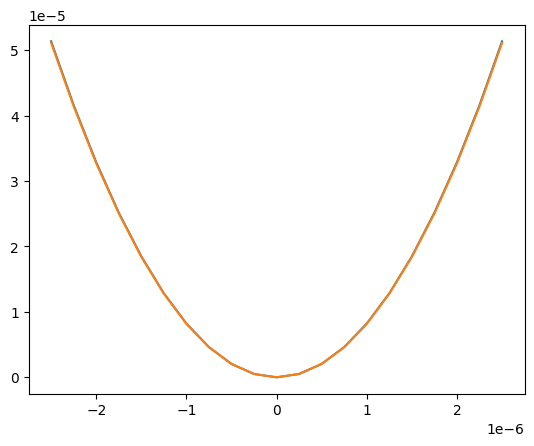

In [14]:
y0_index = np.argmin(np.abs(y_axis - y0))
z0_index = np.argmin(np.abs(z_axis - z0))
target_hessian = np.array([[1, 0, 0], [0, -1/2, 0], [0, 0, -1/2]])*mass*omega**2/(charge)
plt.plot(x_axis, potential_space[:, y0_index, z0_index]-min(potential_space[:, y0_index, z0_index]))
plt.plot(x_axis,1/2*target_hessian[0,0]*(x_axis-0)**2)

Compare to voltage sets we've been using.

In [15]:
x_anstaz = np.array([5.006, -2.408, -2.408, -2.408, 5.006, -0.604, -0.604, 5.006, -2.408, -2.408, -2.408, 5.006])
print_field(A @ x_anstaz, delta_pos=True)

Grad: [ -0.4959215    2.29201892 415.96611278]
Hessian: [[ 1.68131751e+07 -3.49776015e+03 -1.51965989e+04]
 [-3.49776015e+03  9.30444455e+06 -7.37424255e+04]
 [-1.51965989e+04 -7.37424255e+04 -2.61176196e+07]]
Delta Pos (um): [ 0.04386662 -0.12009022 15.92696072]


In [16]:
x_anstaz = np.array([0, 0.58095, -1.6915,0.58095, 0, -0.24083, -0.24083, 0, 0.58095, -1.6915,0.58095, 0])
print_field(A @ x_anstaz, delta_pos=True)

Grad: [ -0.35853785   0.78304673 213.90793574]
Hessian: [[ 1.28886704e+07  4.35620567e+03 -8.52698641e+03]
 [ 4.35620567e+03  4.22727727e+05 -2.23228381e+04]
 [-8.52698641e+03 -2.23228381e+04 -1.33113981e+07]]
Delta Pos (um): [ 0.03878994 -1.00410049 16.07119084]


(not sure if this is a good solution) Fit to a given potential function $f(x)$ with region of interest of width $R$

In [31]:
from post_process import read_post_processed
from field_analysis import analyze_dc_pot

electrode_num = 27
rf_electrode_index = [13]
gnd_electrode_index = [1, 2, 14, 20, 26, 27]
excitation_electrodes = set(range(1, electrode_num + 1)) - set(gnd_electrode_index) - set(rf_electrode_index)
print("DC Excitation Electrodes:", excitation_electrodes)
excitation_electrodes = sorted(excitation_electrodes)
x, y, z, potentials = read_post_processed(filename="dc_transport_sim_out.h5", electrode_list=list(excitation_electrodes))

x_axis = x[:, 0, 0]
y_axis = y[0, :, 0]
z_axis = z[0, 0, :]

DC Excitation Electrodes: {3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25}


In [32]:
print(x_axis)

[-0.00035    -0.00034975 -0.0003495  ...  0.0003495   0.00034975
  0.00035   ]
